In [26]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Optimize binning for DY sample

In [27]:
data_dir= "D:\\Travail\\ZV_analysis\\Numpy\\ZV_2018_btag\\Resolved_DYcr_bVeto\\samples\\v1"
res_dir="D:\\Travail\\ZV_analysis\\2d_binning"

In [29]:
MC_samp=["DY", "ggWW", "top", "tZq", "VBF-V", "VBS_VV_QCD", "VBS_ZV","Vg", "VgS", "VVV", "VZ", "WJets", "WW"]
mc_list=[]
for samp in MC_samp:
    data_list=[]
    for file in os.listdir(data_dir):
        if samp in file:
            mc_list.append(file)
        elif 'DATA' in file: data_list.append(file)
        
for i,file in enumerate(mc_list):
    print(i,file)
    if i == 0 : MC_df=pd.read_pickle(data_dir + '\\'+ file)
    else: MC_df=MC_df.append(pd.read_pickle(data_dir + '\\'+ file))

for i,file in enumerate(data_list):
    print(i,file)
    if i == 0 : data_df=pd.read_pickle(data_dir + '\\'+ file)
    else: data_df=data_df.append(pd.read_pickle(data_dir + '\\'+ file))

0 DY_part1.pkl
1 DY_part10.pkl
2 DY_part2.pkl
3 DY_part3.pkl
4 DY_part4.pkl
5 DY_part5.pkl
6 DY_part6.pkl
7 DY_part7.pkl
8 DY_part8.pkl
9 DY_part9.pkl
10 ggWW_part1.pkl
11 top_part1.pkl
12 top_part2.pkl
13 top_part3.pkl
14 tZq_part1.pkl
15 VBF-V_part1.pkl
16 VBS_VV_QCD_part1.pkl
17 VBS_ZV_part1.pkl
18 VBS_ZV_part2.pkl
19 VgS_part1.pkl
20 VgS_part2.pkl
21 VgS_part3.pkl
22 Vg_part1.pkl
23 VgS_part1.pkl
24 VgS_part2.pkl
25 VgS_part3.pkl
26 VVV_part1.pkl
27 VZ_part1.pkl
28 WJets_part1.pkl
29 ggWW_part1.pkl
30 WW_part1.pkl
0 DATA_part1.pkl
1 DATA_part2.pkl
2 DATA_part3.pkl
3 DATA_part4.pkl


# Compute same populations bins with KDtrees

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


There are 256 groups. biggest - smallest = 101 - 95 = 6


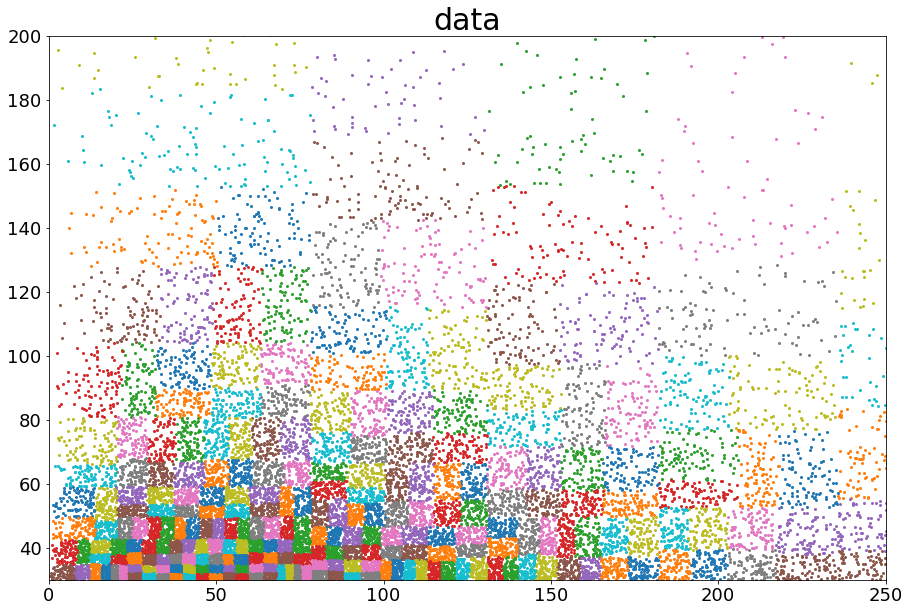

In [33]:
# step1 train kdtree on data, extract bins
data=data_df[[ 'Resolved_DYcr_bVeto_Zleppt','Resolved_DYcr_bVeto_vbs_jet_pt2',]][data_df['weight_']==1]

import numpy as np
from matplotlib import pyplot as plt
from scipy.spatial import cKDTree

tree = cKDTree(data) # let points be an array of shape (n,2)
groups=[]
depth = 7 # depth of the tree, ie: depth=5 results in 64 bins

#function to get bins population (each group correspond to one bin population)
def recurse(node, i=0):
    g = node.greater
    l = node.lesser
    if(i == depth):
        groups.append(g.data_points)
        groups.append(l.data_points)

        return
    recurse(g, i=i+1)
    recurse(l, i=i+1)

recurse(tree.tree)

plt.figure(figsize=(15,10))
# Count the size of bins, rotate points back and plot bins.
list_len = []
for group in groups:
    #points_rot = (j @ group.T).T
    list_len.append(len(group))
    plt.plot(group[:, 0], group[:, 1], 'o', markersize=2)
print(f"There are {len(groups)} groups.", end=' ')
print(f"biggest - smallest = {max(list_len)} - {min(list_len)} = {max(list_len) - min(list_len)}")
plt.xlim(0,250)
plt.ylim(30,200)
plt.title('data')
plt.show()

# bin data following KDtrees bins

In [34]:
%%time

#since I didn't find a way to extract eaisly groups limit, find min/max in each direction

xmins=[]
xmaxs=[]
ymins=[]
ymaxs=[]

for gp in groups:
    xmins.append(gp.T[0].min())
    xmaxs.append(gp.T[0].max())
    ymins.append(gp.T[1].min())
    ymaxs.append(gp.T[1].max())
# find to which bin each event falls in for both data and MC and extract ratio
def binning(x):
    for i,gp in enumerate(groups):
        if ((x.Resolved_DYcr_bVeto_Zleppt > xmins[i]) & (x.Resolved_DYcr_bVeto_Zleppt <xmaxs[i]) & (x.Resolved_DYcr_bVeto_vbs_jet_pt2> ymins[i]) & (x.Resolved_DYcr_bVeto_vbs_jet_pt2 <ymaxs[i])):
            return i

data['bin']=data.apply(binning, axis=1)
MC=MC_df[['Resolved_DYcr_bVeto_Zleppt', 'Resolved_DYcr_bVeto_vbs_jet_pt2', 'weight_']]
MC['bin']=MC.apply(binning, axis=1)
ndatagp=data.groupby('bin').size()
nMCgp=MC.groupby('bin').sum()['weight_']*59.74 #renormalize
ratio=ndatagp/nMCgp

KeyboardInterrupt: 

In [ ]:
from matplotlib import patches
import matplotlib.cm as cm
import matplotlib


norm = matplotlib.colors.Normalize(vmin=0.4, vmax=1.6)
c=[]
for r in ratio:
    c.append(cm.coolwarm(norm(r),bytes=False) )



plt.figure(figsize=(20,15))
ax=plt.gca()
#code to plot the colorbar
a = np.array([[0.4,1.6]])
img = plt.imshow(a, cmap="coolwarm")
# add a rectangle corresponding to each bin
for i,gp in enumerate(groups):
    binw=gp.T[0].max() - gp.T[0].min()
    binh=gp.T[1].max() - gp.T[1].min()
    rect=patches.Rectangle((gp.T[0].min(), gp.T[1].min()), binw, binh, linewidth=1, edgecolor='k', facecolor=c[i])
    ax.add_patch(rect)
ax.set_ylim(0,600)
ax.set_xlim(0,700)
plt.colorbar()
ax.set_ylabel('Second VBS jet')
ax.set_xlabel('Zleppt')
ax.set_title('ratio MC/data')
plt.savefig(res_dir + "//Zleppt+VBS2_{}bins".format(2**(depth+1)))
plt.show()


plt.figure(figsize=(20,15))
ax=plt.gca()
#code to plot the colorbar
a = np.array([[0.2,1.8]])
img = plt.imshow(a, cmap="coolwarm")
# add a rectangle corresponding to each bin
for i,gp in enumerate(groups):
    binw=gp.T[0].max() - gp.T[0].min()
    binh=gp.T[1].max() - gp.T[1].min()
    rect=patches.Rectangle((gp.T[0].min(), gp.T[1].min()), binw, binh, linewidth=1, edgecolor='k', facecolor=c[i])
    ax.add_patch(rect)
ax.set_ylim(30,200)
ax.set_xlim(0,250)
plt.colorbar()
ax.set_ylabel('Second VBS jet')
ax.set_xlabel('Zleppt')
ax.set_title('ratio MC/data')
#plt.savefig(res_dir + "//Zleppt+VBS2_{}bins".format(2**(depth+1)))
plt.show()


In [35]:
#try manual plotting with same kind of binning
data=data_df[[ 'Resolved_DYcr_bVeto_Zleppt','Resolved_DYcr_bVeto_vbs_jet_pt2',]][data_df['weight_']==1]
MC=MC_df[['Resolved_DYcr_bVeto_Zleppt', 'Resolved_DYcr_bVeto_vbs_jet_pt2', 'weight_']]




binx=[30,35,40,45,50,55,65,75,100,125,150,200,250,1000]
biny=[30,35,40,45,50,60,75,100,150,200,1000]


hdata=np.histogram2d(data['Resolved_DYcr_bVeto_Zleppt'], data['Resolved_DYcr_bVeto_vbs_jet_pt2'],bins=(binx,biny))
hmc=np.histogram2d(MC['Resolved_DYcr_bVeto_Zleppt'], MC['Resolved_DYcr_bVeto_vbs_jet_pt2'],bins=(binx,biny), weights=MC['weight_']*59.74)

hratio=hmc[0]/hdata[0]

In [38]:
# ratio mc/data in each bin
hratio

array([[0.95895702, 0.99311094, 1.11981344, 0.80179619, 0.60735608,
        0.87332025, 1.11556495, 1.33145609, 1.13621862, 1.70276438],
       [1.04402356, 0.82891212, 0.88241876, 0.8355342 , 0.84376582,
        1.08437557, 1.06958744, 1.36883911, 1.14182452, 2.80459075],
       [0.94434499, 0.76135593, 0.76116964, 0.89452906, 0.80311101,
        1.06001751, 0.86778081, 0.96347113, 1.16160263, 1.50880536],
       [1.07764932, 0.92846277, 0.89034414, 0.9679664 , 0.92220793,
        1.05407974, 0.72589918, 0.9289152 , 1.55306568, 0.98033956],
       [0.88944532, 0.82904002, 0.83132086, 0.7720095 , 0.84377109,
        0.99468826, 0.91630741, 1.15636829, 1.42753817, 2.18595501],
       [1.07133675, 0.92772256, 0.81417304, 0.98994104, 0.938032  ,
        0.98879947, 1.0656316 , 0.99375852, 1.43792739, 2.04545059],
       [0.92147321, 0.96862352, 0.90350679, 1.02150036, 0.92102702,
        1.08732422, 1.00964395, 0.99744409, 1.10753422, 1.45722258],
       [1.02258096, 0.91233038, 0.9268269

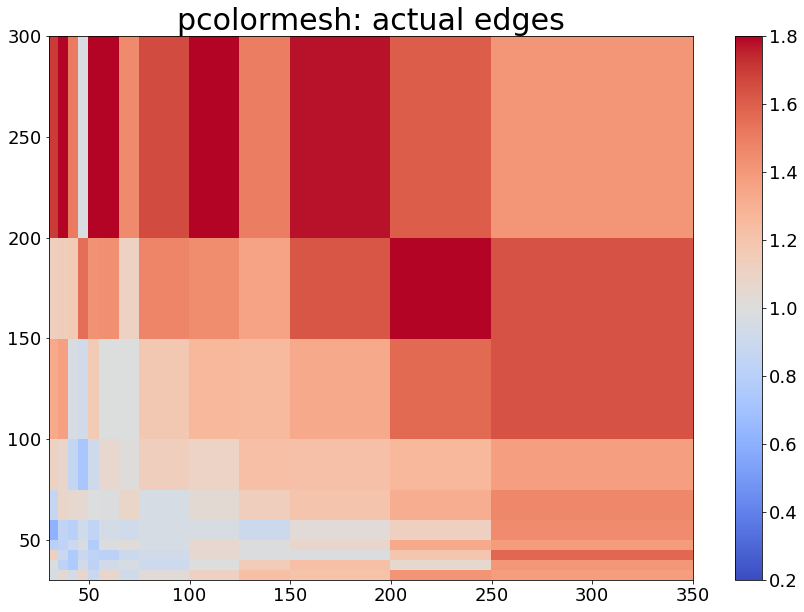

In [39]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, title='pcolormesh: actual edges',
        aspect='equal')
X, Y = np.meshgrid(binx, biny)
im=ax.pcolormesh(X, Y, hratio.T,cmap='coolwarm', vmin=0.2, vmax=1.8)
plt.xlim(30,350)
plt.ylim(30,300)
plt.colorbar(im)
plt.savefig(res_dir + "//Zleppt+VBS1_manual")

# Reduce number of bins for fit (by eye)

In [40]:
def fitbin(x):
    xx= x.Resolved_DYcr_bVeto_Zleppt
    yy=x.Resolved_DYcr_bVeto_vbs_jet_pt2
    if ((xx <=75) & ( yy<=40)) : return 1
    elif ((xx <=75) & (yy>40) & (yy <=70)): return 2
    elif ((xx<=75)&(yy>70) & (yy<=150)): return 3 #too big
    elif((xx>75) &(xx<=130) & (yy<=70)): return 4
    elif ((xx>75) &(xx<=130) & (yy>70) & (yy<=150)): return 5
    elif ((xx>130) & (xx<=230) &( yy<=70)): return 6 # too big
    elif ((xx>130) & (xx<=230) &( yy>70)&(yy<=150)): return 7
    elif ((xx<=230) & (yy>150) & (yy<=250)): return 8
    elif((xx>230) &(xx <= 450) & (yy<=150)):return 9
    elif ((xx>450) ): return 10
    elif((yy>250)):return 11
    elif((xx>230) &(xx<=450) & (yy>150) &(yy<=250)):return 12
    else: return 13

In [45]:
#compute agreement
data['fit']= data.apply(fitbin, axis=1)
datafit=data.groupby('fit').size()
MC['fit']=MC.apply(fitbin, axis=1)
MCfit=MC.groupby('fit').sum()['weight_']*59.74
ratio =datafit/MCfit
ratio

D:\Anaconda\envs\tf-gpu\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


fit
1     1.073399
2     1.127762
3     0.987186
4     1.004615
5     0.871823
6     0.888022
7     0.772161
8     0.680429
9     0.731610
10    0.526328
11    0.534350
12    0.597584
dtype: float64

In [47]:
for i in np.unique(data['fit']) :
    gp= data[data['fit']==i]
    print(i,xmaxs[i-1], xmins[i-1])
    binw=xmaxs[i-1] - xmins[i-1] 
    binh=ymaxs[i-1] - ymins[i-1]
    #print(binw, binh)

1 75 0
2 75 0
3 75 0
4 130 75
5 130 75
6 230 130
7 230 130
8 230 0
9 450 230
10 450 230
11 450 0
12 700 450


# plot fit bins

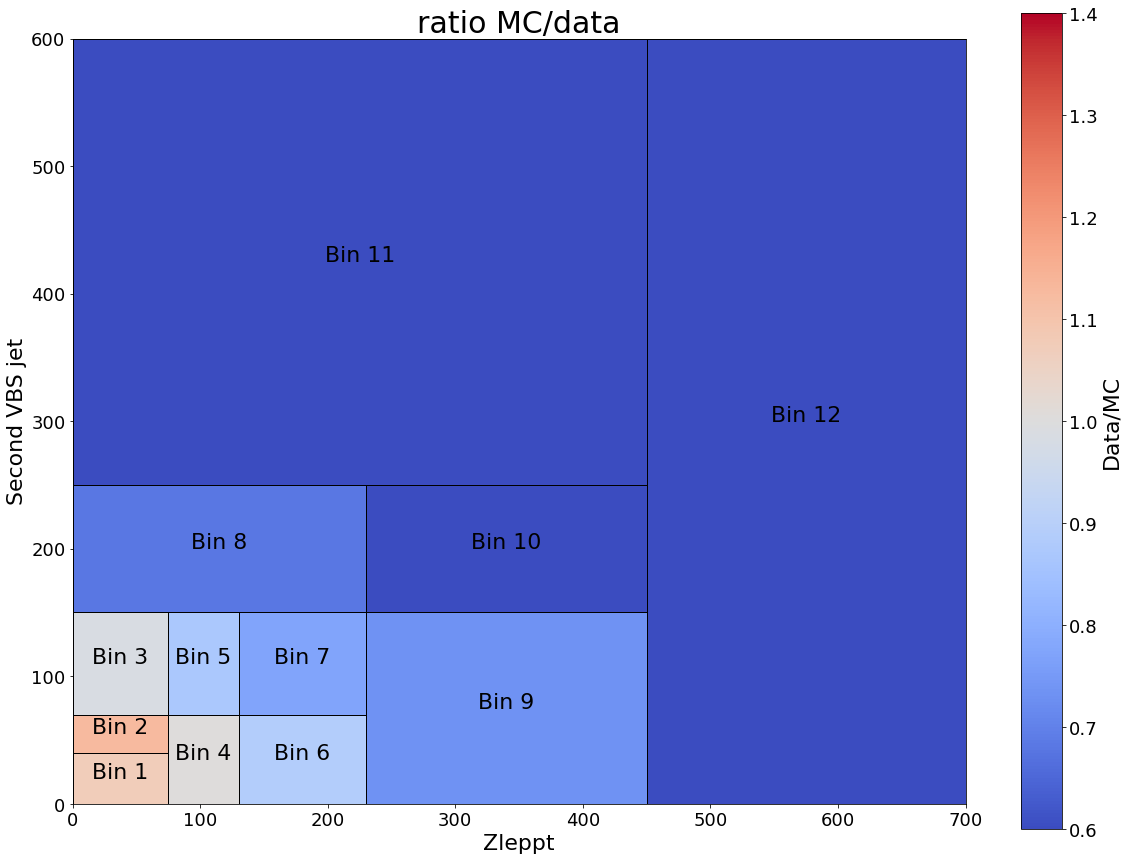

In [52]:
font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 18}
import matplotlib
from matplotlib import patches
import matplotlib.cm as cm
matplotlib.rc('font', **font)
plt.rc('axes', titlesize=30)     # fontsize of the axes title
plt.rc('axes', labelsize=22) 
plt.rc('xtick', labelsize=18) 

norm = matplotlib.colors.Normalize(vmin=0.6, vmax=1.4)
c=[]
for r in ratio:
    c.append(cm.coolwarm(norm(r),bytes=False) )

plt.figure(figsize=(20,15))
ax=plt.gca()
#code to plot the colorbar
a = np.array([[0.6,1.4]])
img = plt.imshow(a, cmap="coolwarm", label='Data/MC')
xmins=[0,0,0,75,75,130,130,0,230,230,0,450]
xmaxs=[75,75,75,130,130,230,230,230,450,450,450,700]
ymins=[0,40,70,0,70,0,70,150,0,150,250,0]
ymaxs=[40,70,150,70,150,70,150,250,150,250,600,600]
# add a rectangle corresponding to each bin
for i in np.unique(data['fit']) :
    gp= data[data['fit']==i]
    binw=xmaxs[i-1] - xmins[i-1] 
    binh=ymaxs[i-1] - ymins[i-1]
    rect=patches.Rectangle(( xmins[i-1], ymins[i-1]), binw, binh, linewidth=1, edgecolor='k', facecolor=c[i-1])
    ax.add_patch(rect)
    centerx = xmins[i-1] + binw/2
    centery = ymins[i-1] + binh/2
    plt.text(centerx, centery,'Bin {}'.format(i), ha='center', fontsize=22)
ax.set_ylim(0,600)
ax.set_xlim(0,700)
plt.colorbar(label='Data/MC')
ax.set_ylabel('Second VBS jet')
ax.set_xlabel('Zleppt')
ax.set_title('ratio MC/data')
plt.savefig(res_dir + "//Zleppt+VBS2_{}bins.pdf".format(2**(depth+1)))
plt.show()
